# M1: hue sensor, filters/ exploration

`PLANhue.md` M1, Goal 2 in `hue_sensor_experiment_notes.md`: the same 10x10 red/green grid `ssveps/`/`beh/` use, read by a 3-channel brightness sensor instead of a person, with a yellow or orange filter (or none) placed in front of it, in both a 10Hz-flickering and a non-flickering (`solid`) modality. Six files: `{solid,flash} x {F,NF,Or}`.

This notebook is exploration only (`PLANhue.md`): raw channel data in full, one trial's shape up close, a first per-trial aggregation attempt, and the resulting grid view.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import loader
import plotting

df = loader.load_filters()
df['condition'] = df['flicker'] + '_' + df['filter']
df.groupby('condition').size()

condition
flash_F     5150
flash_NF    5150
flash_Or    5150
solid_F     3516
solid_NF    3516
solid_Or    3516
dtype: int64

## Goal 1 (from the notes doc): the whole channel data, completely

Every raw sample of `HueR`/`HueG`/`HueB`, in original recording order, one panel per condition -- no per-trial summarizing yet.

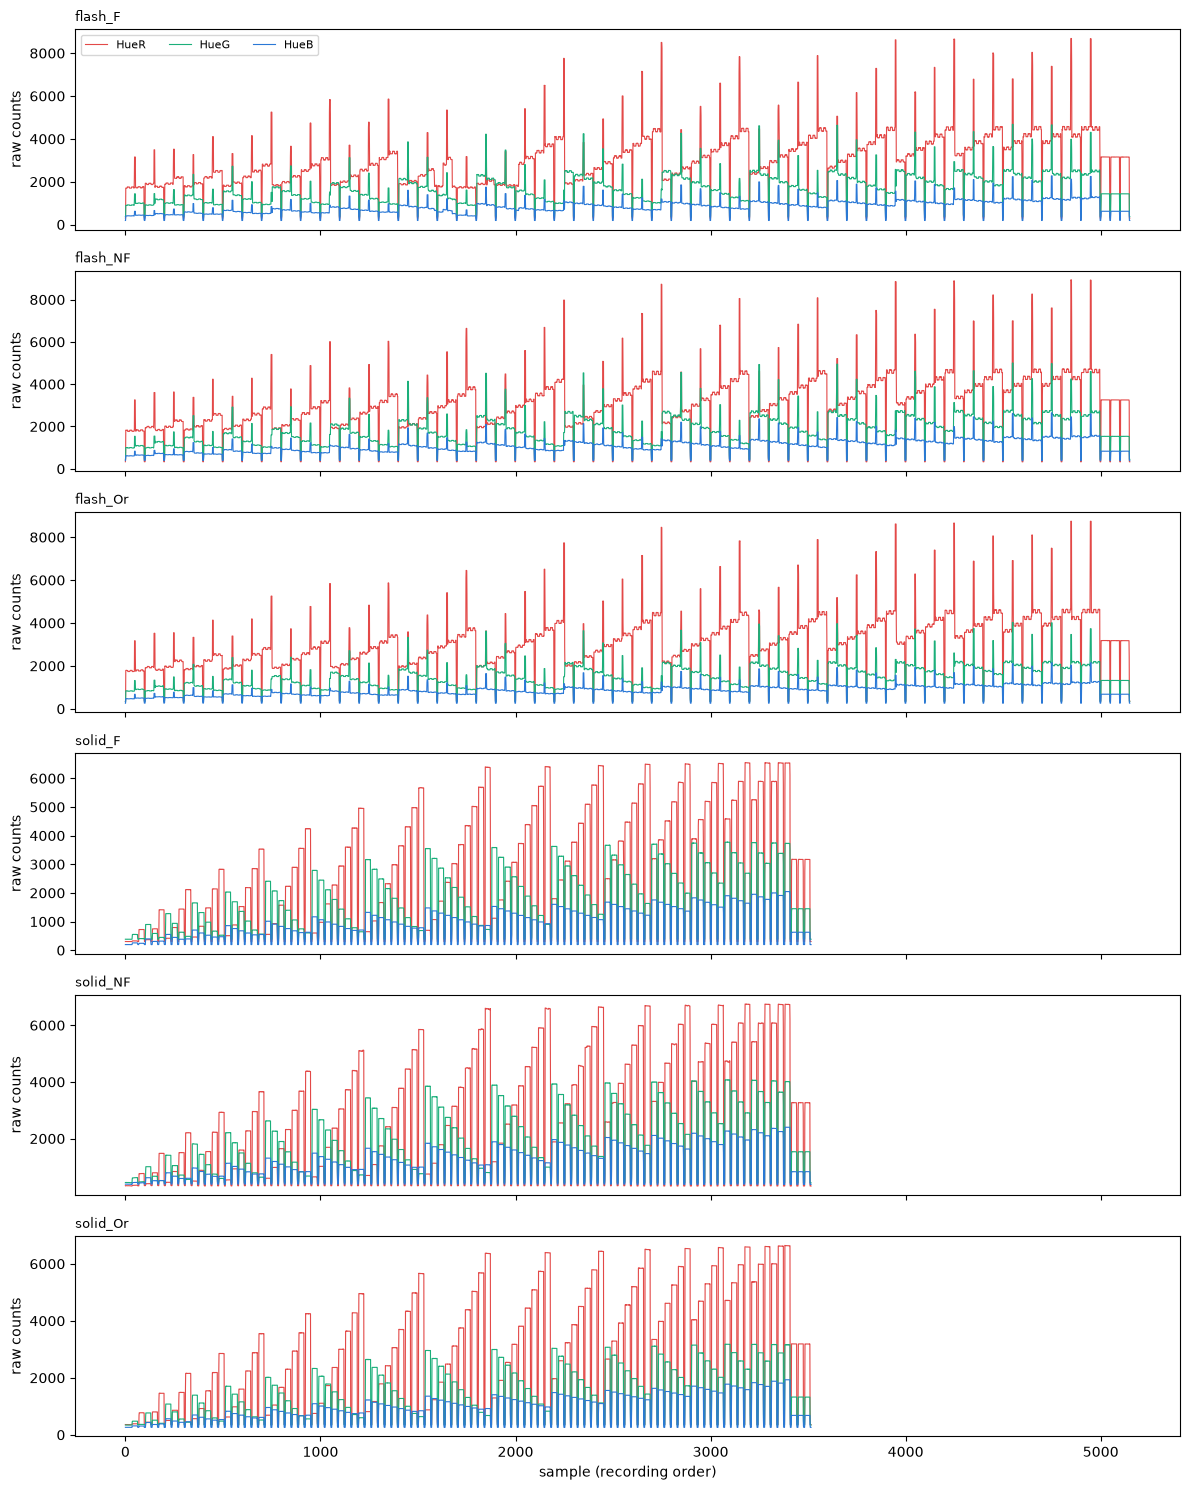

In [2]:
plotting.plot_channel_overview(df, group_col='condition');

The `flash_*` conditions show a repeating pattern (a fast rise, a plateau, then a transition into the next grid cell) once per grid cell -- the sensor is picking up the 10Hz flicker's *envelope* changing as the red/green mix changes across the grid, not the individual 10Hz cycles themselves (each sample is ~110ms, too slow to resolve a 10Hz flicker directly). The `solid_*` conditions are flatter overall, as expected with no flicker -- what structure remains still tracks the red/green grid stepping through its 100 cells.

## One trial, up close

`flash_NF` (no filter, flickering) at the grid's strongest red cell (`Red=3200, Green=0`) -- to see the onset/plateau/offset shape within a single `Stim` block before deciding how to aggregate it.

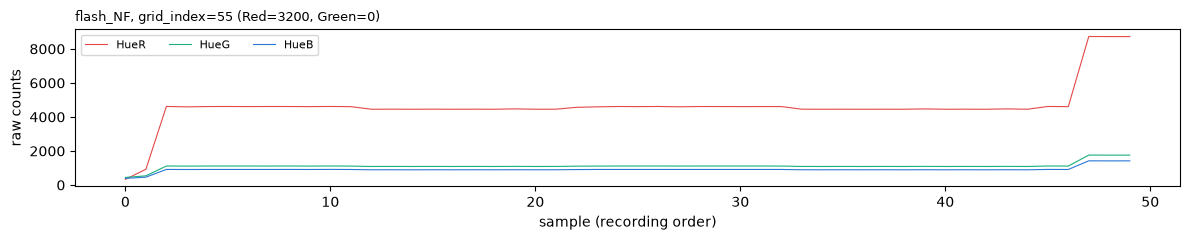

In [3]:
flash_nf = df[df['condition'] == 'flash_NF']
grid_only = flash_nf[~flash_nf['is_baseline']]
strong_red_gi = grid_only.loc[(grid_only['Red'] == 3200) & (grid_only['Green'] == 0), 'grid_index'].iloc[0]
one_trial = grid_only[grid_only['grid_index'] == strong_red_gi].assign(condition=f'flash_NF, grid_index={int(strong_red_gi)} (Red=3200, Green=0)')
plotting.plot_channel_overview(one_trial, group_col='condition');

Not a clean onset-plateau-offset: the first ~2 samples still show the *previous* stimulus's value, the middle (roughly sample 3-45) is a genuinely stable plateau, and the last 3 samples jump to ~8700 -- far above this cell's own plateau of ~4600. That's not this trial decaying; it's the *next* trial's transition already leaking in. Grid cells aren't presented in simple raster order: `grid_index=55` here is `Red=3200, Green=0`, but `grid_index=56` (immediately next in the file) is `Red=355, Green=2000` -- close to the largest possible jump on the grid. Switching between two such different stimuli visibly overshoots, and the `Stim` label boundary lands in the middle of that transient rather than after it settles, so it contaminates both trials' edges, not just one. `EDGE_TRIM=3` below happens to clear both ends for this example; worth checking it holds up across cells with smaller neighbor-to-neighbor jumps too.

## A first per-trial aggregation attempt

Not promoted to `scripts/` yet (`PLANhue.md`) -- prototyped here so it's easy to change `EDGE_TRIM` and see the grid view below update.

In [4]:
EDGE_TRIM = 3  # samples dropped from each end of a Stim block, per the single-trial shape above

def aggregate_grid(condition_df, edge_trim=EDGE_TRIM):
    """Mean HueR/HueG/HueB per grid cell, dropping edge_trim samples from
    each end of every Stim block to exclude the onset/offset transient."""
    grid = condition_df[~condition_df['is_baseline']]
    rows = []
    for (red, green), g in grid.groupby(['Red', 'Green']):
        g = g.sort_values('sample_idx')
        trimmed = g.iloc[edge_trim:-edge_trim] if len(g) > 2 * edge_trim else g
        rows.append({'Red': red, 'Green': green, 'HueR': trimmed['HueR'].mean(), 'HueG': trimmed['HueG'].mean(), 'HueB': trimmed['HueB'].mean(), 'n_samples': len(trimmed)})
    return pd.DataFrame(rows)

agg_flash_nf = aggregate_grid(flash_nf)
agg_flash_nf.describe()

,Red,Green,HueR,HueG,HueB,n_samples
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
mean,1599.600000,999.600000,3156.604091,1836.314545,1080.990455,44.0
std,1026.353868,641.453715,882.679117,555.090203,251.997872,0.0
min,0.000000,0.000000,1797.113636,991.840909,610.727273,44.0
25%,711.000000,444.000000,2405.295455,1318.147727,868.994318,44.0
50%,1599.500000,999.500000,3117.431818,1849.136364,1078.113636,44.0
75%,2488.000000,1555.000000,3900.000000,2331.068182,1290.579545,44.0
max,3200.000000,2000.000000,4688.818182,2725.886364,1544.750000,44.0


## The channel-perception grid

`flash_NF` (no filter): each panel is one sensor channel's response across the full red/green grid.

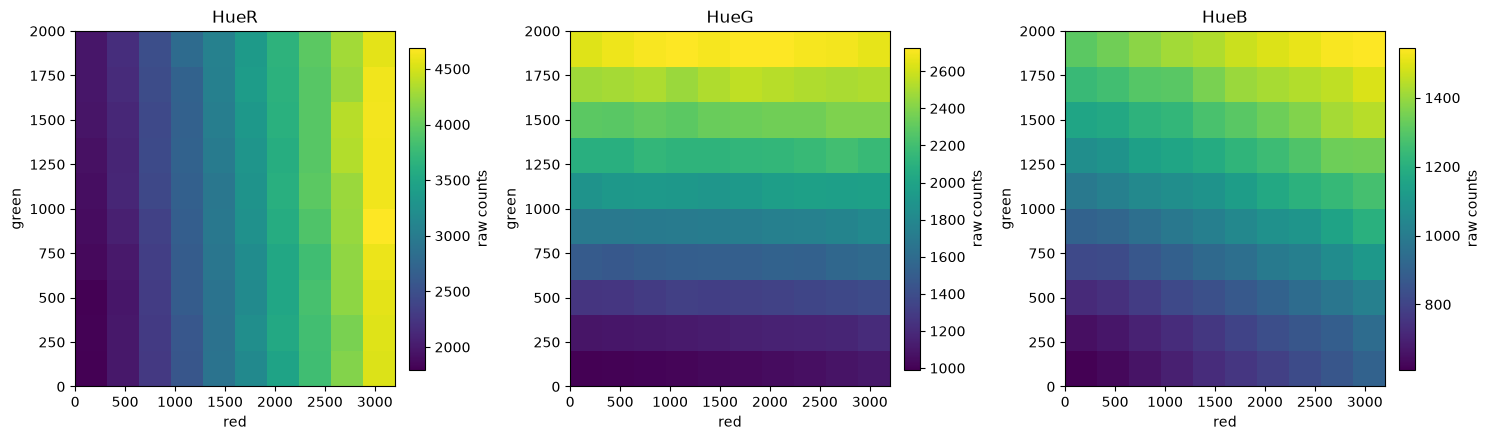

In [5]:
plotting.plot_channel_grid(agg_flash_nf);

`HueR` tracks the red D/A value almost linearly, as expected. `HueG` and `HueB` also rise somewhat with red (not just with their own channel) -- a mild crosstalk in the sensor's own filtering, not a bug: worth keeping in mind for the goal-3 (`flashDiff/`) work, where isolating one LED's contribution assumes the sensor's channels are cleanly separated.

## A first look at the filter effect (Goal 2)

Same aggregation, all six conditions -- how much does each filter shift the grid's overall channel readings, and does flicker change that shift?

In [6]:
summary_rows = []
for condition, sub in df.groupby('condition'):
    agg = aggregate_grid(sub)
    summary_rows.append({'condition': condition, 'mean_HueR': agg['HueR'].mean(), 'mean_HueG': agg['HueG'].mean(), 'mean_HueB': agg['HueB'].mean()})
pd.DataFrame(summary_rows).sort_values('condition')

,condition,mean_HueR,mean_HueG,mean_HueB
0,flash_F,2989.047500,1696.066591,830.623409
1,flash_NF,3156.604091,1836.314545,1080.990455
2,flash_Or,3109.229773,1494.404545,857.011136
3,solid_F,3133.476379,1902.042365,1036.568165
4,solid_NF,3241.862081,2071.640493,1306.947808
5,solid_Or,3208.323054,1621.379889,1019.503670


Grid-averaged channel means, one row per condition -- a first, coarse look at each filter's effect before going cell-by-cell. `Or` (orange) and `F` (yellow) should shift the channel balance differently from each other and from `NF` (no filter) if they're going to be useful CVD-simulation proxies; whether `flash` vs `solid` changes that shift is the flicker-isolation question the notes doc raises. Worth a closer, per-cell comparison (not just the grid average) as a next step, once the aggregation window above is more settled.